# 🏠 House Price Prediction — Ames Iowa
## Numerical Features Edition | TS Academy Assignment

**Dataset:** Ames Housing Dataset (Kaggle)  
**Objective:** Predict `SalePrice` using only numerical features. Every cleaning, engineering, and modelling decision is explicitly justified in markdown cells above each code block.

---

## 1. Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100

# Set display options for DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 120)
pd.set_option('display.width', 1000)

In [ ]:
train = pd.read_csv('/content/drive/MyDrive/House Prices Prediction/train.csv')
test = pd.read_csv('/content/drive/MyDrive/House Prices Prediction/test.csv')

In [ ]:
train.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1.5Fin,5,5,1993,1995,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,Wood,Gd,TA,No,GLQ,732,Unf,0,64,796,GasA,Ex,Y,SBrkr,796,566,0,1362,1,0,1,1,1,1,TA,5,Typ,0,NaN,Attchd,1993.0,Unf,2,480,TA,TA,Y,40,30,0,320,0,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,8,5,2004,2005,Gable,CompShg,VinylSd,VinylSd,Stone,186.0,Gd,TA,PConc,Ex,TA,Av,GLQ,1369,Unf,0,317,1686,GasA,Ex,Y,SBrkr,1694,0,0,1694,1,0,2,0,3,1,Gd,7,Typ,1,Gd,Attchd,2004.0,RFn,2,636,TA,TA,Y,255,57,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,PosN,Norm,1Fam,2Story,7,6,1973,1973,Gable,CompShg,HdBoard,HdBoard,Stone,240.0,TA,TA,CBlock,Gd,TA,Mn,ALQ,859,BLQ,32,216,1107,GasA,Ex,Y,SBrkr,1107,983,0,2090,1,0,2,1,3,1,TA,7,Typ,2,TA,Attchd,1973.0,RFn,2,484,TA,TA,Y,235,204,228,0,0,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,1Fam,1.5Fin,7,5,1931,1950,Gable,CompShg,BrkFace,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0,Unf,0,952,952,GasA,Gd,Y,FuseF,1022,752,0,1774,0,0,2,0,2,2,TA,8,Min1,2,TA,Detchd,1931.0,Unf,2,468,Fa,TA,Y,90,0,205,0,0,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,BrkSide,Artery,Artery,2fmCon,1.5Unf,5,6,1939,1950,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,BrkTil,TA,TA,No,GLQ,851,Unf,0,140,991,GasA,Ex,

In [ ]:
train.shape

(1460, 81)

In [ ]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [ ]:
test.shape

(1459, 80)

In [ ]:
test.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
5,1466,60,RL,75.0,10000,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1993,1994,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0.0,Unf,0.0,763.0,763.0,GasA,Gd,Y,SBrkr,763,892,0,1655,0.0,0.0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1993.0,Fin,2.0,440.0,TA,TA,Y,157,84,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal
6,1467,20,RL,NaN,7980,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,1Story,6,7,1992,2007,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,TA,Gd,PConc,Gd,TA,No,ALQ,935.0,Unf,0.0,233.0,1168.0,GasA,Ex,Y,SBrkr,1187,0,0,1187,1.0,0.0,2,0,3,1,TA,6,Typ,0,NaN,Attchd,1992.0,Fin,2.0,420.0,TA,TA,Y,483,21,0,0,0,0,NaN,GdPrv,Shed,500,3,2010,WD,Normal
7,1468,60,RL,63.0,8402,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1998,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0.0,Unf,0.0,789.0,789.0,GasA,Gd,Y,SBrkr,789,676,0,1465,0.0,0.0,2,1,3,1,TA,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,393.0,TA,TA,Y,0,75,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal
8,1469,20,RL,85.0,10176,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,1Story,7,5,1990,1990,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,TA,TA,PConc,Gd,TA,Gd,GLQ,637.0,Unf,0.0,663.0,1300.0,GasA,Gd,Y,SBrkr,1341,0,0,1341,1.0,0.0,1,1,2,1,Gd,5,Typ,1,Po,Attchd,1990.0,Unf,2.0,506.0,TA,TA,Y,192,0,0,0,0,0,NaN,NaN,NaN,0,2,2010,WD,Normal
9,1470,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,4,5,1970,1970,Gable,CompShg,Plywood

In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
print("Missing values in train dataframe:")
print(train.isna().sum()[train.isna().sum() > 0])

print("\nMissing values in test dataframe:")
print(test.isna().sum()[test.isna().sum() > 0])

Missing values in train dataframe:
LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

Missing values in test dataframe:
MSZoning           4
LotFrontage      227
Alley           1352
Utilities          2
Exterior1st        1
Exterior2nd        1
MasVnrType       894
MasVnrArea        15
BsmtQual          44
BsmtCond          45
BsmtExposure      44
BsmtFinType1      42
BsmtFinSF1         1
BsmtFinType2      42
BsmtFinSF2         1
BsmtUnfSF          1
TotalBsmtSF        1
BsmtFullBath       2
BsmtHalfBath       2
KitchenQual        1
Functional         2
FireplaceQu      730
GarageType        76
GarageYrBlt       78
GarageFinish  

In [ ]:
num_cols = [c for c in train.select_dtypes(include=['int64', 'float64']).columns if c != 'Id']
train_num = train[num_cols].copy()
test_num = test.select_dtypes(include=['int64', 'float64']).drop(columns=['Id']).copy()

# Check missing values BEFORE cleaning
print("Missing values before cleaning (train):")
print(train_num.isnull().sum()[train_num.isnull().sum() > 0])

Missing values before cleaning (train):
LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64


In [ ]:
# Check missing values AFTER cleaning
print(f"Missing after cleaning — train: {train_num.isnull().sum().sum()}, test: {test_num.isnull().sum().sum()}")

Missing after cleaning — train: 348, test: 330


In [ ]:
num_cols = [c for c in train.select_dtypes(include=['int64', 'float64']).columns if c != 'Id']

In [ ]:
train_num = train[num_cols].copy()
test_num = test.select_dtypes(include=['int64', 'float64']).drop(columns=['Id']).copy()

In [ ]:
print(f"Numerical features (excl. Id): {len(num_cols)}")
print("\nFull feature list:")
print(num_cols)

Numerical features (excl. Id): 37

Full feature list:
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']


In [ ]:
# Compute correlation matrix
corr_matrix = train_num.corr()

In [ ]:
# Get top 5 features most correlated with SalePrice (excluding SalePrice itself)
top5 = corr_matrix['SalePrice'].abs().sort_values(ascending=False).iloc[1:6]



In [ ]:
# Display results
print("Top 5 features by absolute correlation with SalePrice:\n")
print(top5.to_string())

Top 5 features by absolute correlation with SalePrice:

OverallQual    0.790982
GrLivArea      0.708624
GarageCars     0.640409
GarageArea     0.623431
TotalBsmtSF    0.613581


In [ ]:

# Define corr_matrix first
corr_matrix = train_num.corr()

top10_feats = corr_matrix['SalePrice'].abs().sort_values(ascending=False).head(11).index

In [ ]:

plt.figure(figsize=(12, 9))


<Figure size 1200x900 with 0 Axes>

<Figure size 1200x900 with 0 Axes>

<Axes: >

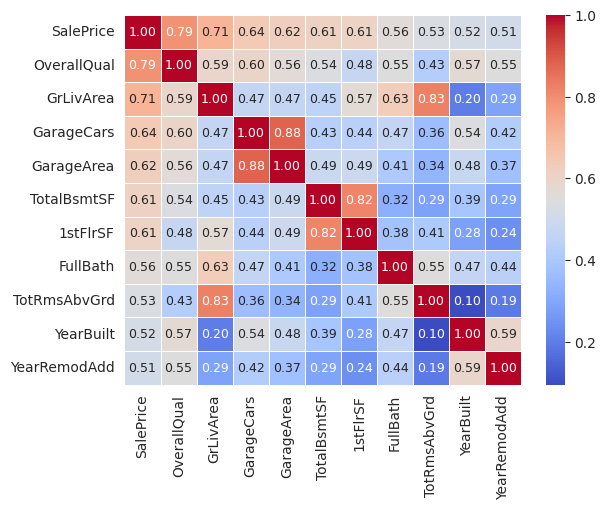

In [ ]:
# 3. Generate the Heatmap
sns.heatmap(
    train_num[top10_feats].corr(),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
)



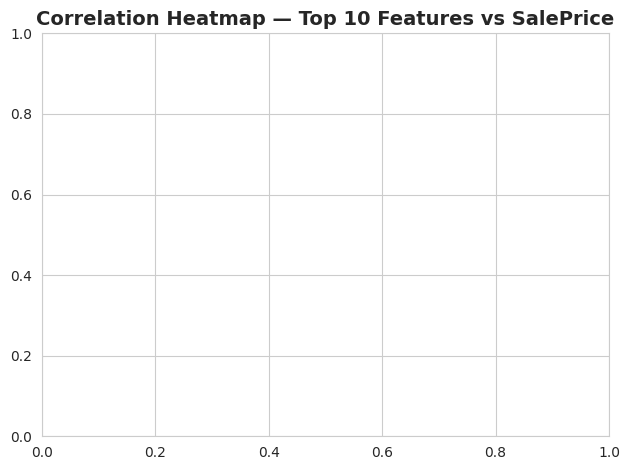

In [ ]:
# 4. Add title and adjust layout
plt.title('Correlation Heatmap — Top 10 Features vs SalePrice', fontsize=14, fontweight='bold')
plt.tight_layout()



In [ ]:
# 5. Save the output as an image and display it
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
# 1. Configuration
top3 = ['OverallQual', 'GrLivArea', 'GarageCars']
colors = ['#2196F3', '#4CAF50', '#FF5722']



Text(0.5, 0.98, 'Top 3 Features vs SalePrice')

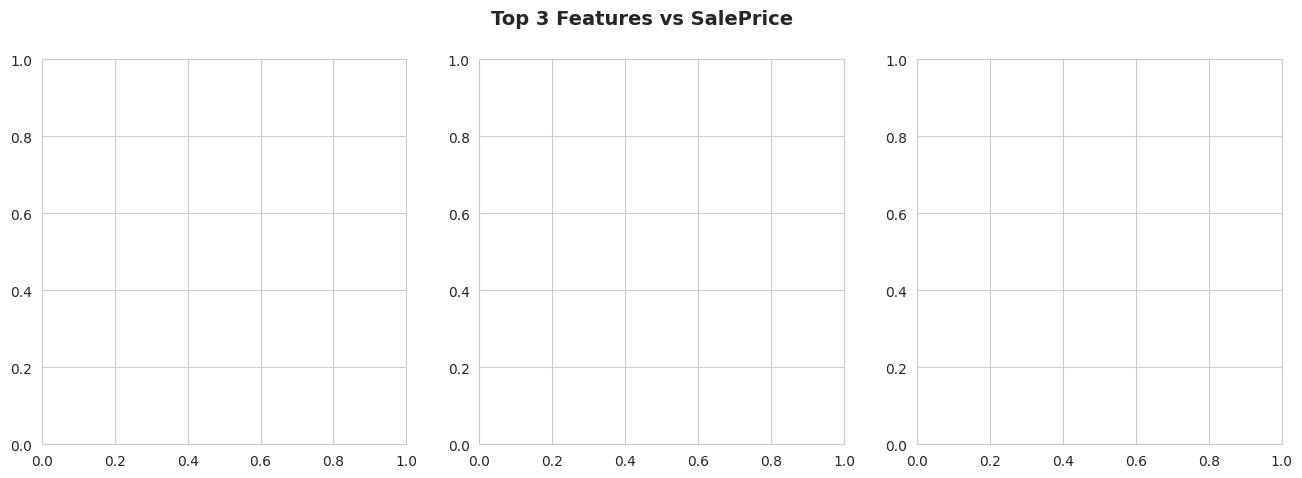

In [ ]:
# 2. Initialize the plot (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Top 3 Features vs SalePrice', fontsize=14, fontweight='bold')



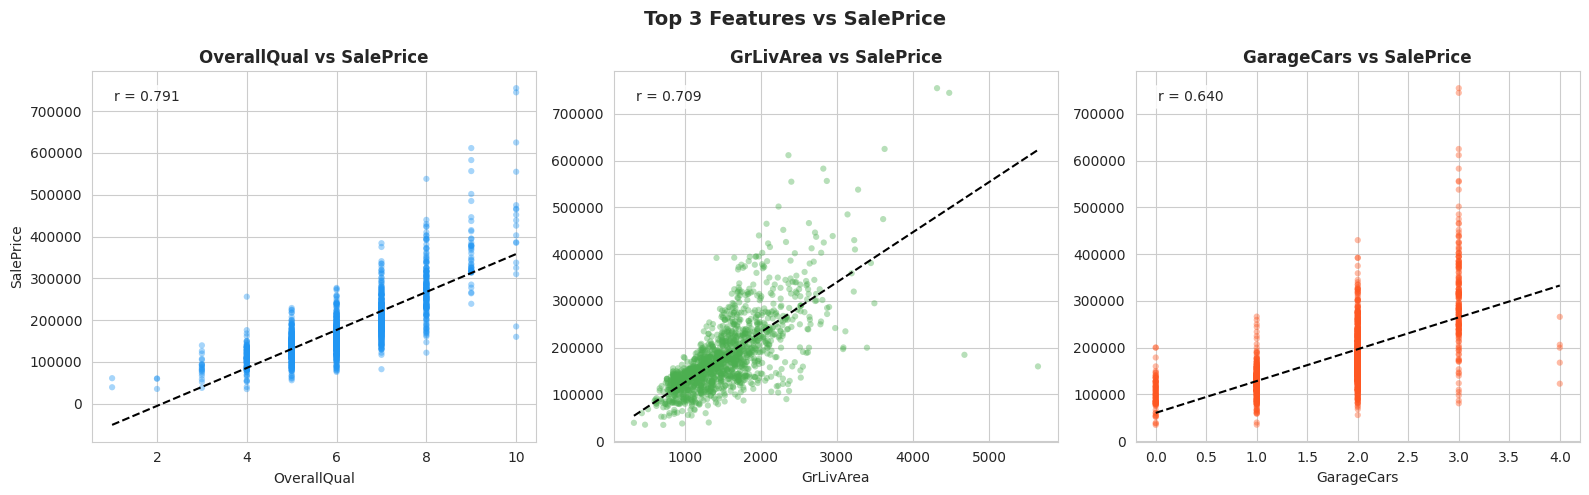

In [ ]:
# Top 3 features
top3 = ['OverallQual', 'GrLivArea', 'GarageCars']
colors = ['#2196F3', '#4CAF50', '#FF5722']

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Top 3 Features vs SalePrice', fontsize=14, fontweight='bold')

# Loop through each feature
for feat, ax, color in zip(top3, axes, colors):
    ax.scatter(
        train_num[feat],
        train_num['SalePrice'],
        alpha=0.4,
        color=color,
        s=20,
        edgecolors='none'
    )

    # Fit regression line
    m, b = np.polyfit(train_num[feat], train_num['SalePrice'], 1)
    x_line = np.linspace(train_num[feat].min(), train_num[feat].max(), 100)
    ax.plot(x_line, m * x_line + b, color='black', lw=1.5, linestyle='--')

    # Correlation
    r = train_num[[feat, 'SalePrice']].corr().iloc[0, 1]

    # Labels and title
    ax.set_xlabel(feat)
    if feat == top3[0]:
        ax.set_ylabel('SalePrice')
    else:
        ax.set_ylabel('')

    ax.set_title(f'{feat} vs SalePrice', fontweight='bold')

    # Annotate correlation
    ax.annotate(
        f'r = {r:.3f}',
        xy=(0.05, 0.92),
        xycoords='axes fraction',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
    )

# Layout and save
plt.tight_layout()
plt.savefig('scatter_top3.png', dpi=150, bbox_inches='tight')
plt.show()

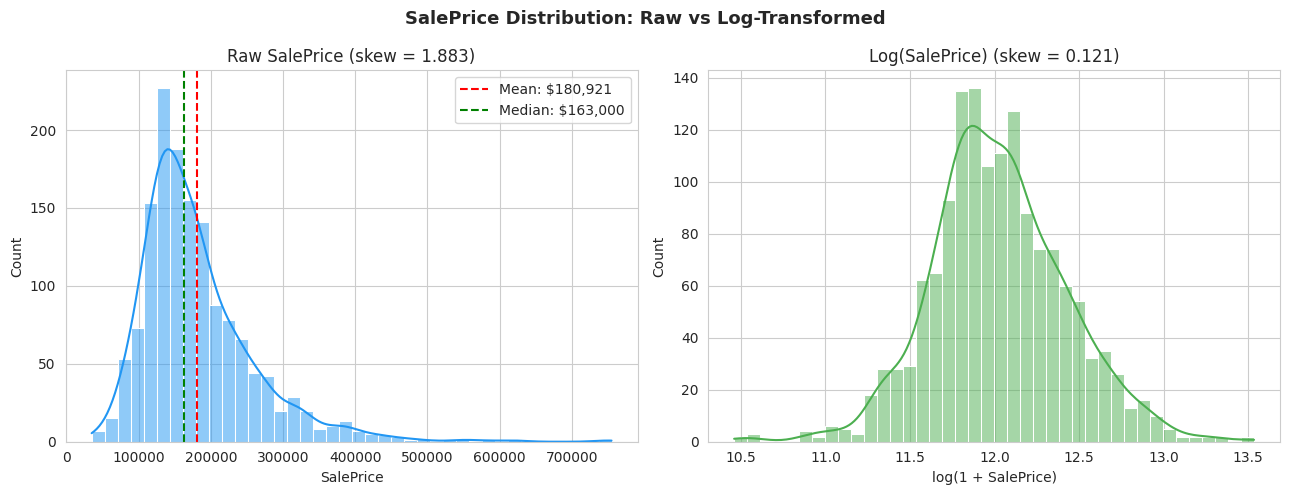

Raw skew: 1.8829 | Log skew: 0.1213


In [ ]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('SalePrice Distribution: Raw vs Log-Transformed', fontsize=13, fontweight='bold')

# Raw SalePrice distribution
sns.histplot(train_num['SalePrice'], kde=True, ax=axes[0], color='#2196F3', bins=40)
skew_raw = train_num['SalePrice'].skew()

axes[0].set_title(f'Raw SalePrice (skew = {skew_raw:.3f})')

# Mean and Median lines
axes[0].axvline(
    train_num['SalePrice'].mean(),
    color='red',
    linestyle='--',
    lw=1.5,
    label=f"Mean: ${train_num['SalePrice'].mean():,.0f}"
)

axes[0].axvline(
    train_num['SalePrice'].median(),
    color='green',
    linestyle='--',
    lw=1.5,
    label=f"Median: ${train_num['SalePrice'].median():,.0f}"
)

axes[0].legend()

# Log-transformed SalePrice
log_price = np.log1p(train_num['SalePrice'])

sns.histplot(log_price, kde=True, ax=axes[1], color='#4CAF50', bins=40)

axes[1].set_title(f'Log(SalePrice) (skew = {log_price.skew():.3f})')
axes[1].set_xlabel('log(1 + SalePrice)')

# Layout and save
plt.tight_layout()
plt.savefig('saleprice_dist.png', dpi=150, bbox_inches='tight')
plt.show()

# Print skew values
print(f"Raw skew: {skew_raw:.4f} | Log skew: {log_price.skew():.4f}")

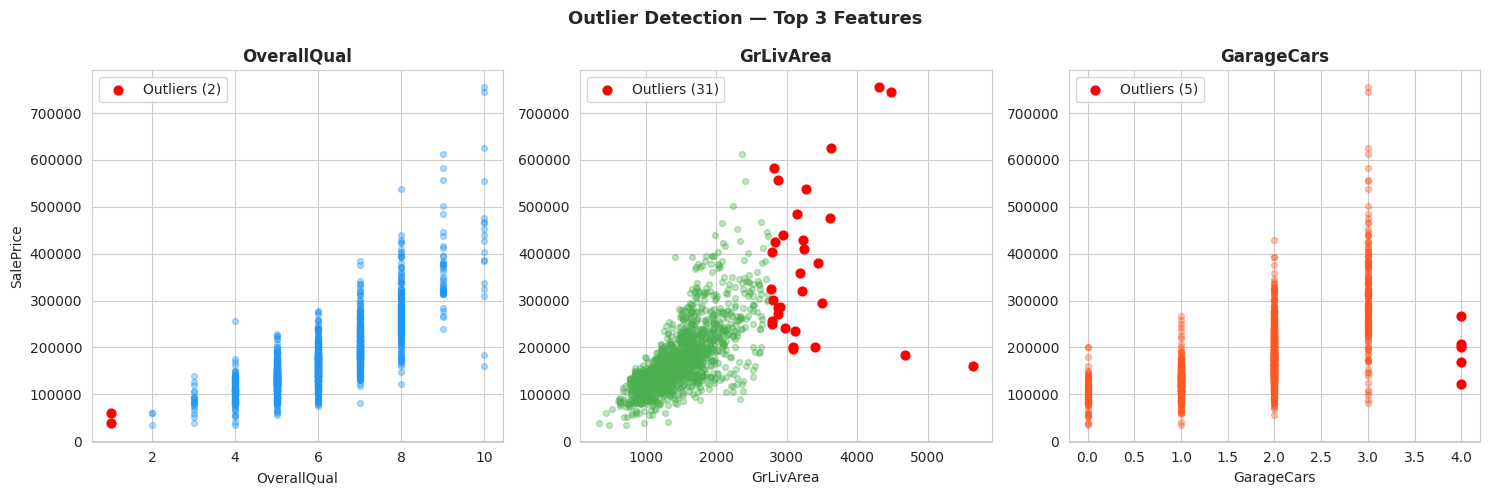

Dropping 2 anomalous rows: index [523, 1298]
Training set size after drop: (1458, 37)


In [ ]:
# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Outlier Detection — Top 3 Features', fontsize=13, fontweight='bold')

# Features to check
features_o = ['OverallQual', 'GrLivArea', 'GarageCars']
colors_o = ['#2196F3', '#4CAF50', '#FF5722']

# Loop through features
for feat, ax, color in zip(features_o, axes, colors_o):
    Q1 = train_num[feat].quantile(0.25)
    Q3 = train_num[feat].quantile(0.75)
    IQR = Q3 - Q1

    # Identify outliers
    outliers = train_num[
        (train_num[feat] < (Q1 - 1.5 * IQR)) |
        (train_num[feat] > (Q3 + 1.5 * IQR))
    ]

    # Non-outliers
    normal = train_num[~train_num.index.isin(outliers.index)]

    # Plot normal points
    ax.scatter(normal[feat], normal['SalePrice'], alpha=0.35, color=color, s=18)

    # Plot outliers
    ax.scatter(outliers[feat], outliers['SalePrice'],
               color='red', s=40, zorder=5,
               label=f'Outliers ({len(outliers)})')

    # Labels
    ax.set_xlabel(feat)
    if feat == features_o[0]:
        ax.set_ylabel('SalePrice')
    else:
        ax.set_ylabel('')

    ax.set_title(feat, fontweight='bold')
    ax.legend()

# Layout and save
plt.tight_layout()
plt.savefig('outliers.png', dpi=150, bbox_inches='tight')
plt.show()


# Drop anomalous GrLivArea rows (extreme size but low price)
drop_idx = train_num[
    (train_num['GrLivArea'] > 4000) &
    (train_num['SalePrice'] < 200000)
].index

print(f"Dropping {len(drop_idx)} anomalous rows: index {list(drop_idx)}")

# Remove them
train_num = train_num.drop(index=drop_idx).reset_index(drop=True)

print(f"Training set size after drop: {train_num.shape}")

In [ ]:
# Check missing values before cleaning
print("Missing values before cleaning (train):")
print(train_num.isnull().sum()[train_num.isnull().sum() > 0])

# Median for LotFrontage
lot_median = train_num['LotFrontage'].median()
print(f"\nLotFrontage median (imputation value): {lot_median} ft")

# Apply imputations (train)
train_num = train_num.assign(
    LotFrontage=train_num['LotFrontage'].fillna(lot_median),
    GarageYrBlt=train_num['GarageYrBlt'].fillna(0),
    MasVnrArea=train_num['MasVnrArea'].fillna(0)
)

# Apply imputations (test)
test_num = test_num.assign(
    LotFrontage=test_num['LotFrontage'].fillna(lot_median),
    GarageYrBlt=test_num['GarageYrBlt'].fillna(0),
    MasVnrArea=test_num['MasVnrArea'].fillna(0)
)

# Fill any remaining missing values in test using training medians
for col in test_num.columns:
    if test_num[col].isnull().sum() > 0:
        fill_val = train_num[col].median() if col in train_num.columns else 0
        test_num = test_num.assign(**{col: test_num[col].fillna(fill_val)})

# Final check
print(f"\nMissing after cleaning — train: {train_num.isnull().sum().sum()}, test: {test_num.isnull().sum().sum()}")

Missing values before cleaning (train):
LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64

LotFrontage median (imputation value): 69.0 ft

Missing after cleaning — train: 0, test: 0


In [ ]:
# Select feature columns (exclude target)
feat_cols = [c for c in train_num.columns if c != 'SalePrice']

# Correlation matrix (absolute values)
corr_feats = train_num[feat_cols].corr().abs()

# Find highly correlated feature pairs (|r| > 0.8)
high_pairs = []
for i in range(len(corr_feats.columns)):
    for j in range(i + 1, len(corr_feats.columns)):
        if corr_feats.iloc[i, j] > 0.8:
            high_pairs.append(
                (corr_feats.columns[i], corr_feats.columns[j], corr_feats.iloc[i, j])
            )

print("Feature pairs with |r| > 0.8:")

# Sort and display pairs with their correlation to SalePrice
for a, b, v in sorted(high_pairs, key=lambda x: -x[2]):
    corr_a = abs(train_num[[a, 'SalePrice']].corr().iloc[0, 1]) if a in train_num.columns else 0
    corr_b = abs(train_num[[b, 'SalePrice']].corr().iloc[0, 1]) if b in train_num.columns else 0

    print(f"  {a} ({corr_a:.3f}) — {b} ({corr_b:.3f}): pair r = {v:.3f}")

# Columns to drop based on multicollinearity judgment
drop_mc = ['GarageArea', '1stFlrSF', 'TotRmsAbvGrd']

# Drop from train and test
train_num = train_num.drop(columns=drop_mc)
test_num = test_num.drop(columns=[c for c in drop_mc if c in test_num.columns])

print(f"\nDropped: {drop_mc}")
print(f"Remaining features: {train_num.shape[1] - 1} (excluding SalePrice)")

Feature pairs with |r| > 0.8:
  GarageCars (0.641) — GarageArea (0.629): pair r = 0.887
  GrLivArea (0.735) — TotRmsAbvGrd (0.538): pair r = 0.829
  TotalBsmtSF (0.651) — 1stFlrSF (0.632): pair r = 0.804

Dropped: ['GarageArea', '1stFlrSF', 'TotRmsAbvGrd']
Remaining features: 33 (excluding SalePrice)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Target variables
y_raw = train_num['SalePrice'].copy()
y_log = np.log1p(y_raw)

# Features
X = train_num.drop(columns=['SalePrice']).copy()
X_test_raw = test_num.copy()

# Initialize scaler
scaler = StandardScaler()

# Fit on training data, transform both train and test
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_raw),
    columns=X.columns
)

# Checks
print(f"Scaling complete. X_scaled shape: {X_scaled.shape}")
print(f"Feature means (should be ~0): {X_scaled.mean().abs().max():.6f} max")
print(f"Feature stds  (should be ~1): {X_scaled.std().abs().mean():.6f} mean")

Scaling complete. X_scaled shape: (1458, 33)
Feature means (should be ~0): 0.000000 max
Feature stds  (should be ~1): 1.000343 mean


In [ ]:
# Function to add new features
def add_features(df):
    df = df.copy()

    # Total square footage
    df['TotalSF'] = (
        df.get('TotalBsmtSF', pd.Series(0, index=df.index)) +
        df.get('GrLivArea', pd.Series(0, index=df.index))
    )

    # Age of the house at sale
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']

    # Total bathrooms (weighted)
    df['TotalBathrooms'] = df['FullBath'] + 0.5 * df['HalfBath']

    # Years since last remodel
    df['YearsSinceRemodel'] = df['YrSold'] - df['YearRemodAdd']

    return df

# Apply feature engineering
X_fe = add_features(X)
X_test_fe = add_features(X_test_raw)

# Summary of new features
print("New features summary:")
print(
    X_fe[['TotalSF', 'HouseAge', 'TotalBathrooms', 'YearsSinceRemodel']]
    .describe()
    .round(1)
)

New features summary:
       TotalSF  HouseAge  TotalBathrooms  YearsSinceRemodel
count   1458.0    1458.0          1458.0             1458.0
mean    2563.0      36.6             1.8               23.0
std      776.2      30.2             0.6               20.6
min      334.0       0.0             0.0                0.0
25%     2014.0       8.0             1.0                4.0
50%     2476.5      35.0             2.0               14.0
75%     3005.5      54.0             2.5               41.0
max     6872.0     136.0             3.5               60.0


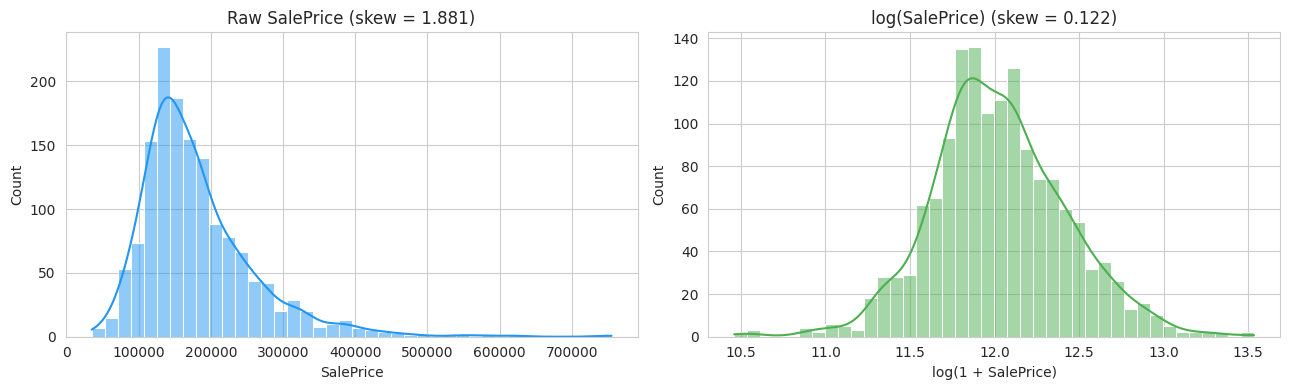

In [ ]:
# Log-transform target
y_log = np.log1p(train_num['SalePrice'])

# Create plots
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Raw SalePrice
sns.histplot(
    train_num['SalePrice'],
    kde=True,
    ax=axes[0],
    color='#2196F3',
    bins=40
)
axes[0].set_title(f"Raw SalePrice (skew = {train_num['SalePrice'].skew():.3f})")

# Log-transformed SalePrice
sns.histplot(
    y_log,
    kde=True,
    ax=axes[1],
    color='#4CAF50',
    bins=40
)
axes[1].set_title(f"log(SalePrice) (skew = {y_log.skew():.3f})")
axes[1].set_xlabel('log(1 + SalePrice)')

# Layout
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Initialize the Scaler
scaler2 = StandardScaler()


X_final = pd.DataFrame(
    scaler2.fit_transform(X_fe),
    columns=X_fe.columns
)


X_test_final = pd.DataFrame(
    scaler2.transform(X_test_fe),
    columns=X_fe.columns
)


print(f"Final training matrix: {X_final.shape}")
print(f"Final test matrix:     {X_test_final.shape}")
print(f"Features: {list(X_final.columns)}")

Final training matrix: (1458, 37)
Final test matrix:     (1459, 37)
Features: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'TotalSF', 'HouseAge', 'TotalBathrooms', 'YearsSinceRemodel']


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

# 1. Setup the K-Fold strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Initializing the model
lr = LinearRegression()

mse_scores = cross_val_score(lr, X_final, y_log, cv=kf, scoring='neg_mean_squared_error')
lr_scores = np.sqrt(-mse_scores)

# 4. Results Reporting
print("Linear Regression — 5-Fold CV (RMSE on log SalePrice):")
for i, s in enumerate(lr_scores, 1):
    print(f"  Fold {i}: {s:.4f}")

print(f"\n  Mean RMSE: {lr_scores.mean():.4f}")
print(f"  Std RMSE:  {lr_scores.std():.4f}")

# 5. Success Check
# 0.16 set as a  baseline for log-error performance
success = lr_scores.mean() < 0.16
print(f"\n  Success criterion (< 0.16): {'✅ PASS' if success else '❌ FAIL'}")

Linear Regression — 5-Fold CV (RMSE on log SalePrice):
  Fold 1: 0.1328
  Fold 2: 0.1191
  Fold 3: 0.1408
  Fold 4: 0.1326
  Fold 5: 0.1188

  Mean RMSE: 0.1288
  Std RMSE:  0.0086

  Success criterion (< 0.16): ✅ PASS


In [ ]:
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import cross_val_score
import numpy as np


alphas = [0.01, 0.1, 1, 5, 10, 20, 50, 100, 200, 500]

# 2. RidgeCV to automatically find the best alpha using 5-fold Cross-Validation
ridge_selector = RidgeCV(alphas=alphas, cv=5)
ridge_selector.fit(X_final, y_log)
best_alpha = ridge_selector.alpha_

print(f"Best alpha selected by RidgeCV: {best_alpha}")



ridge_model = Ridge(alpha=best_alpha)
mse_scores = cross_val_score(ridge_model, X_final, y_log, cv=kf, scoring='neg_mean_squared_error')
ridge_scores = np.sqrt(-mse_scores)

# 4. Results Reporting
print("\nRidge Regression — 5-Fold CV (RMSE on log SalePrice):")
for i, s in enumerate(ridge_scores, 1):
    print(f"  Fold {i}: {s:.4f}")

print(f"\n  Mean RMSE: {ridge_scores.mean():.4f}")
print(f"  Std RMSE:  {ridge_scores.std():.4f}")

# 5. Performance Comparison
improvement = lr_scores.mean() - ridge_scores.mean()
print(f"\n  Improvement over Linear: {improvement:+.4f}")

success = ridge_scores.mean() < 0.16
print(f"  Success criterion (< 0.16): {'✅ PASS' if success else '❌ FAIL'}")

Best alpha selected by RidgeCV: 10.0

Ridge Regression — 5-Fold CV (RMSE on log SalePrice):
  Fold 1: 0.1329
  Fold 2: 0.1189
  Fold 3: 0.1403
  Fold 4: 0.1325
  Fold 5: 0.1191

  Mean RMSE: 0.1287
  Std RMSE:  0.0084

  Improvement over Linear: +0.0001
  Success criterion (< 0.16): ✅ PASS


best alpha: 10.0


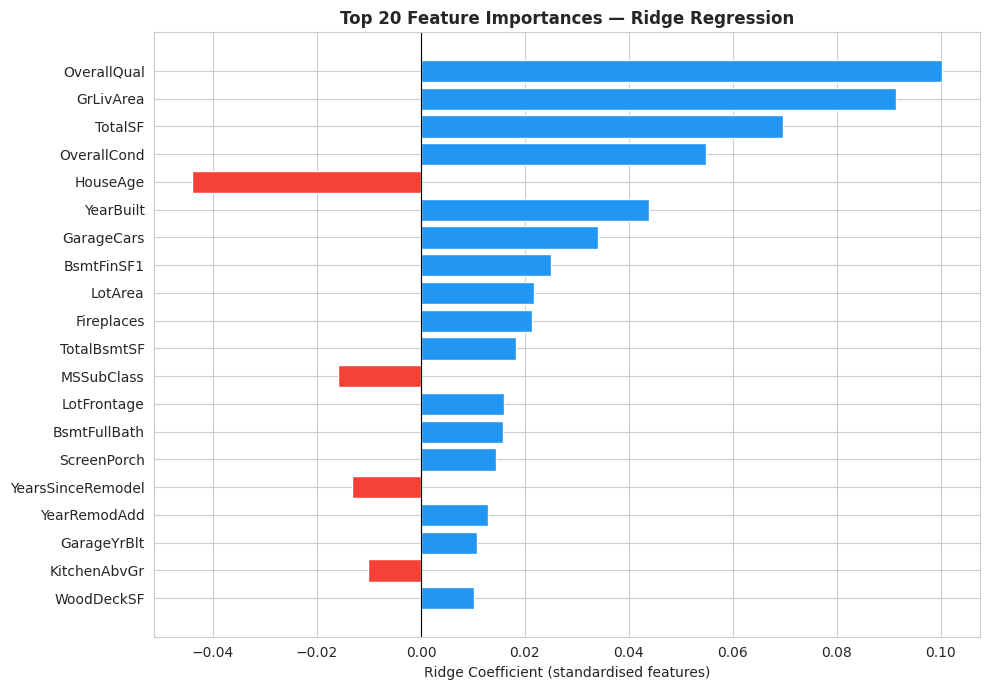

In [ ]:
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

alphas = [0.01, 0.1, 5, 10, 20, 50, 100, 200, 500]
ridge_selector = RidgeCV(alphas=alphas, cv=5)
ridge_selector.fit(X_final, y_log)
best_alpha = ridge_selector.alpha_
print(f"best alpha: {best_alpha}")

# fit on full training set
ridge_final = Ridge(alpha=best_alpha)
ridge_final.fit(X_final, y_log)

# see which features Ridge weighted most
coef_df = pd.DataFrame({'Feature': X_final.columns, 'Coefficient': ridge_final.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
top20 = coef_df.head(20)

plt.figure(figsize=(10, 7))
bar_colors = ['#2196F3' if c > 0 else '#F44336' for c in top20['Coefficient'][::-1]]
plt.barh(top20['Feature'][::-1], top20['Coefficient'][::-1], color=bar_colors)
plt.xlabel('Ridge Coefficient (standardised features)')
plt.title('Top 20 Feature Importances — Ridge Regression', fontweight='bold')
plt.axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.savefig('coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import numpy as np

test_ids = test['Id']


preds_log = ridge_final.predict(X_test_final)

# 3. # log1p was applied to SalePrice during training, expm1 reverses that
preds_price = np.expm1(preds_log)

# 4. Create the submission DataFrame
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': preds_price
})

# 5. Export to CSV to view the result
submission.to_csv('submission.csv', index=False)

# 6. quick look at the first few predictions
print("Submission saved: submission.csv")
print("-" * 30)
print(submission.head(10))

print(f"\nPrediction statistics:")
print(f"  Min:    ${preds_price.min():>12,.0f}")
print(f"  Max:    ${preds_price.max():>12,.0f}")
print(f"  Mean:   ${preds_price.mean():>12,.0f}")
print(f"  Median: ${np.median(preds_price):>12,.0f}")

Submission saved: submission.csv
------------------------------
     Id      SalePrice
0  1461  118574.700289
1  1462  144166.089233
2  1463  176647.838906
3  1464  197420.143089
4  1465  180765.837969
5  1466  172557.130026
6  1467  192464.481485
7  1468  163446.972279
8  1469  195420.877579
9  1470  115623.957576

Prediction statistics:
  Min:    $      52,996
  Max:    $   1,745,834
  Mean:   $     178,635
  Median: $     158,310
